In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [121]:
from pathlib import Path

blog_visuals = Path("../visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

def export_figure(fig, filename, dpi=220, width_px=None, aspect=None, tight=False, pad_inches=0.08):
    if width_px is not None and aspect is not None:
        fig.set_size_inches(width_px / dpi, (width_px * aspect) / dpi)
    out = blog_visuals / filename
    bbox = "tight" if tight else None
    fig.savefig(out, dpi=dpi, bbox_inches=bbox, pad_inches=pad_inches)
    print(f"Saved figure: {out.resolve()}")
    return out

def md_image(path, display_width_px=680):
    rel = path.relative_to(blog_visuals.parent)
    print(f"<img class=\"post-figure\" src=\"{rel.as_posix()}\" width=\"{display_width_px}\" />")

In [102]:
def elo_expected_score(rating_white, rating_black):
    return 1 / (1 + 10 ** ((rating_black - rating_white) / 400))

def predict_outcome_probs(rating_white, rating_black, model):
    abs_diff = abs(rating_white - rating_black)
    p_draw = float(model.predict_proba(pd.DataFrame({"abs_rating_diff": [abs_diff]}))[0, 1])

    e_white = elo_expected_score(rating_white, rating_black)
    p_white_win = e_white - 0.5 * p_draw
    p_black_win = (1 - e_white) - 0.5 * p_draw

    probs = np.array([p_white_win, p_draw, p_black_win], dtype=float)
    probs = np.clip(probs, 0, None)
    probs = probs / probs.sum()

    return {"white_win": float(probs[0]), "draw": float(probs[1]), "black_win": float(probs[2])}

Overall draw rate: 0.602


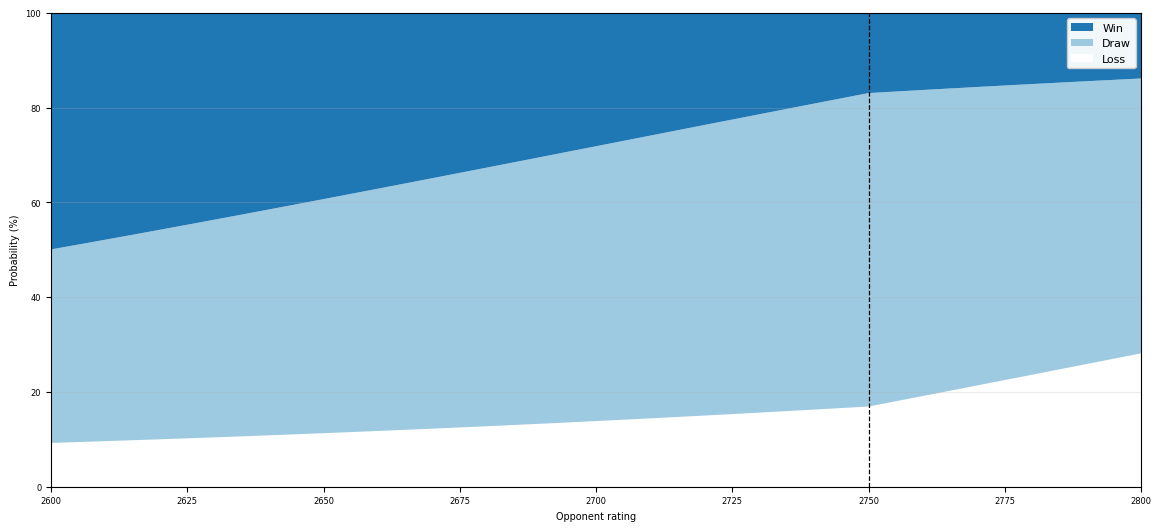

In [122]:
matches = pd.read_csv("data/matches.csv")

analysis = matches.copy()
analysis["abs_rating_diff"] = (analysis["white_rating"] - analysis["black_rating"]).abs()
analysis["is_draw"] = (analysis["result"] == "Draw").astype(int)
overall_draw_rate = analysis["is_draw"].mean()
print(f"Overall draw rate: {overall_draw_rate:.3f}")

X = analysis[["abs_rating_diff"]]
y = analysis["is_draw"]
draw_model = LogisticRegression(solver="lbfgs")
draw_model.fit(X, y)

opponents = np.arange(2600, 2801, 1)
probs = [predict_outcome_probs(2750, opp, draw_model) for opp in opponents]
win_pct = 100 * np.array([p["white_win"] for p in probs])
loss_pct = 100 * np.array([p["black_win"] for p in probs])
draw_pct = 100 * np.array([p["draw"] for p in probs])

fig, ax = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
areas = ax.stackplot(
    opponents, loss_pct, draw_pct, win_pct,
    colors=["white", "#9ecae1", "tab:blue"], edgecolor="none"
)
ax.axvline(2750, color="black", linestyle="--", linewidth=0.9)

ax.set_xlim(opponents.min(), opponents.max())
ax.margins(x=0)
ax.set_xlabel("Opponent rating", fontsize=7)
ax.set_ylabel("Probability (%)", fontsize=7)
ax.set_ylim(0, 100)
ax.tick_params(axis="both", labelsize=6)
ax.legend(
    [areas[2], areas[1], areas[0]], ["Win", "Draw", "Loss"],
    loc="upper right", fontsize=8,
    frameon=True, facecolor="white", edgecolor="0.8", framealpha=0.95,
)
ax.grid(axis="y", alpha=0.25)

fig_draw_probs = fig
plt.show()

In [104]:
def simulate_game(rating_white, rating_black, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    probs = predict_outcome_probs(rating_white, rating_black, draw_model)
    outcomes = ["white_win", "draw", "black_win"]
    return rng.choice(outcomes, p=[probs["white_win"], probs["draw"], probs["black_win"]])


def simulate_tournament(ratings, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    scores = np.zeros(8, dtype=float)

    for i in range(8):
        for j in range(i + 1, 8):
            for white, black in [(i, j), (j, i)]:
                result = simulate_game(ratings[white], ratings[black], rng=rng)
                if result == "white_win":
                    scores[white] += 1.0
                elif result == "draw":
                    scores[white] += 0.5
                    scores[black] += 0.5
                else:
                    scores[black] += 1.0

    top_score = scores.max()
    leaders = np.flatnonzero(scores == top_score)
    winner_idx = int(rng.choice(leaders))

    distinct_desc = np.sort(np.unique(scores))[::-1]
    runner_up_score = float(distinct_desc[1]) if distinct_desc.size > 1 else float(top_score)
    target_score = runner_up_score + 0.5
    wins_required = (target_score - 7) / 0.5

    return winner_idx, wins_required


def shannon_entropy_bits(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def simulate_tournament_distribution(ratings, n_sims, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    winners = np.empty(n_sims, dtype=int)
    wins_required = np.empty(n_sims, dtype=float)

    for s in range(n_sims):
        winner_idx, target_wins = simulate_tournament(ratings, rng=rng)
        winners[s] = winner_idx
        wins_required[s] = target_wins

    winner_probs = np.bincount(winners, minlength=8) / n_sims
    entropy_bits = shannon_entropy_bits(winner_probs)
    effective_field_size = float(2 ** entropy_bits)

    return effective_field_size, float(wins_required.mean())


In [105]:
ratings_raw = pd.read_csv("data/ratings.csv")

all_setups = [
    ("Slugfest", "Example setups", [2800] * 8),
    ("Race", "Example setups", [2800] * 2 + [2700] * 6),
    *((str(y), "Candidates setups",
       ratings_raw.loc[ratings_raw["year"] == y, "rating"].sort_values(ascending=False).tolist())
      for y in sorted(ratings_raw["year"].unique())),
]

rows = []
for label, group, ratings in all_setups:
    effective_field_size, wins_required = simulate_tournament_distribution(ratings, n_sims=10000)
    rows.append({"label": label, "group": group,
                 "effective_field_size": effective_field_size, "wins_required": wins_required})

sim_summary = pd.DataFrame(rows)


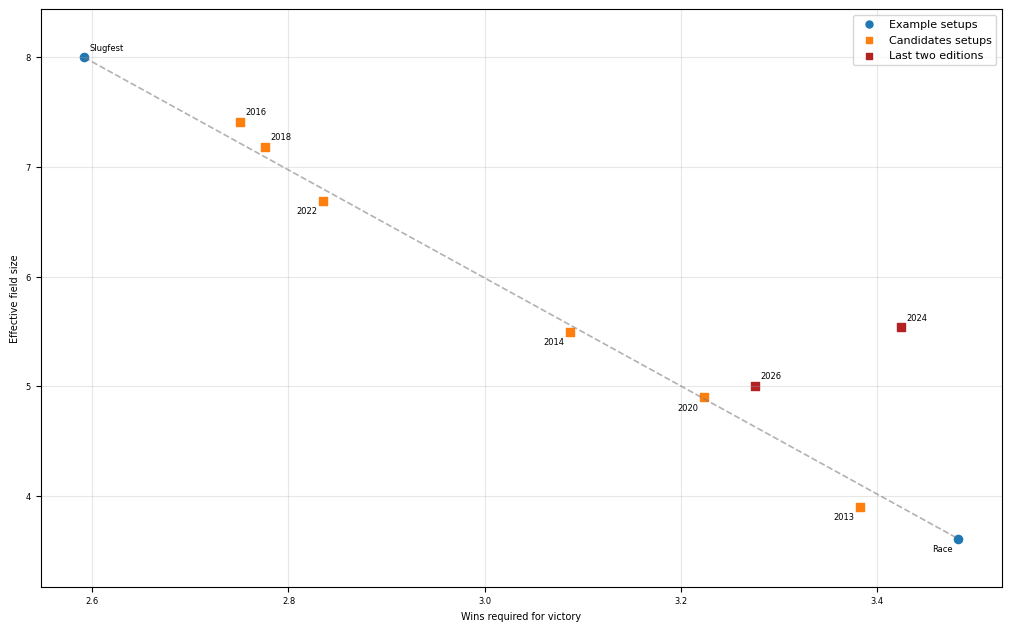

In [131]:
fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)

plot_df = sim_summary.copy()

example_points = plot_df[plot_df["group"] == "Example setups"]
candidates_points = plot_df[plot_df["group"] == "Candidates setups"]
highlighted = candidates_points[candidates_points["label"].isin(["2024", "2026"])]
other_candidates = candidates_points[~candidates_points["label"].isin(["2024", "2026"])]

ax.scatter(example_points["wins_required"], example_points["effective_field_size"],
           s=35, label="Example setups")
ax.scatter(other_candidates["wins_required"], other_candidates["effective_field_size"],
           s=35, marker="s", label="Candidates setups")
ax.scatter(highlighted["wins_required"], highlighted["effective_field_size"],
           s=35, marker="s", color="firebrick", label="Last two editions")

slugfest = example_points[example_points["label"] == "Slugfest"].iloc[0]
race = example_points[example_points["label"] == "Race"].iloc[0]
ax.plot([slugfest["wins_required"], race["wins_required"]],
        [slugfest["effective_field_size"], race["effective_field_size"]],
        linestyle="--", linewidth=1.2, color="0.45", alpha=0.55)

labels_top_right = [
    "Slugfest", "2016", "2018", "2024", "2026",
]
labels_bottom_left = [
    "Race", "2013", "2014", "2020", "2022"
]

all_points = pd.concat([example_points, candidates_points], ignore_index=True)
for _, r in all_points.iterrows():
    label = str(r["label"])
    if label in labels_bottom_left:
        dx, dy = -4, -4
        ha, va = "right", "top"
    else:
        dx, dy = 4, 4
        ha, va = "left", "bottom"

    ax.annotate(
        label,
        (r["wins_required"], r["effective_field_size"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=6,
        ha=ha,
        va=va,
    )

ax.margins(y=0.10)
ax.set_xlabel("Wins required for victory", fontsize=7)
ax.set_ylabel("Effective field size", fontsize=7)
ax.tick_params(axis="both", labelsize=6)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, markerscale=0.85)
fig_effective_field = fig
plt.show()

In [132]:
draw_probs_path = export_figure(fig_draw_probs, "elo-results.png", width_px=1200, aspect=0.45)
effective_field_path = export_figure(fig_effective_field, "tournament-comparison.png", width_px=1200, aspect=0.62, tight=False, pad_inches=0.05)
md_image(draw_probs_path)
md_image(effective_field_path)

Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.04 Chess Candidates/visuals/elo-results.png
Saved figure: /Users/vik.shirvaikar/Desktop/Sports/vshirvaikar.github.io/blog/2026.04 Chess Candidates/visuals/tournament-comparison.png
<img class="post-figure" src="visuals/elo-results.png" width="680" />
<img class="post-figure" src="visuals/tournament-comparison.png" width="680" />
